In [47]:
import os
import pickle
import pandas as pd
from typing import Dict
from datetime import datetime

from azureml.core import Workspace, Datastore, Dataset

# Paths
EXPOSURE_PATH = "p1_postop/SSL/exposure/preop.csv"
OUTCOME_PATH = "p1_postop/SSL/targets/ARF.csv"
MAPPING_PATH = "Zahra/032026/Data_OOT/PreMEDS_MDPS/hash_to_integer_map.pkl"
DATASTORE_NAME = "researcher_data"

# Azure config
SUBSCRIPTION_ID = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
RESOURCE_GROUP = 'forskerpl-n0ybkr-rg'
WORKSPACE_NAME = 'forskerpl-n0ybkr-mlw'

# Columns
TIMESTAMP_COL = 'time'
PID_COL = 'subject_id'
ABSPOS_COL = 'abspos'

# Time window
START_DATE = "2020-01-01"
END_DATE = "2021-06-01"

In [48]:
def get_workspace():
    return Workspace(
        subscription_id=SUBSCRIPTION_ID,
        resource_group=RESOURCE_GROUP,
        workspace_name=WORKSPACE_NAME
    )

ws = get_workspace()
print("Workspace loaded")

Workspace loaded


In [49]:
def print_dataset_summary(exposure_df, outcome_df, title="Dataset Summary"):
    print(f"\n===== {title} =====")
    
    print(f"Exposure data:")
    print(f"   - Records: {len(exposure_df):,}")
    print(f"   - Unique patients: {exposure_df[PID_COL].nunique():,}")
    
    print(f"\nOutcome data:")
    print(f"   - Records: {len(outcome_df):,}")
    print(f"   - Unique patients: {outcome_df[PID_COL].nunique():,}")

In [50]:
def read_csv_from_datastore(ws, datastore_name, path, rename_dict=None):
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, path))
    local_path = dataset.download("./temp", overwrite=True)[0]
    df = pd.read_csv(local_path)

    if rename_dict:
        df = df.rename(columns=rename_dict)

    return df

exposure = read_csv_from_datastore(
    ws, DATASTORE_NAME, EXPOSURE_PATH,
    rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
)

outcome = read_csv_from_datastore(
    ws, DATASTORE_NAME, OUTCOME_PATH,
    rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
)

print("Exposure rows:", len(exposure))
print("Outcome rows:", len(outcome))

Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Exposure rows: 767161
Outcome rows: 1786


In [51]:
def clean_data(df):
    df = df.dropna(subset=[TIMESTAMP_COL, PID_COL])
    df = df.drop_duplicates()
    return df

exposure = clean_data(exposure)
outcome = clean_data(outcome)

print("After cleaning:")
print("Exposure:", len(exposure))
print("Outcome:", len(outcome))

After cleaning:
Exposure: 767161
Outcome: 1786


In [52]:
print_dataset_summary(exposure, outcome, title="Before Filtering")


===== Before Filtering =====
Exposure data:
   - Records: 767,161
   - Unique patients: 526,364

Outcome data:
   - Records: 1,786
   - Unique patients: 1,711


In [53]:
def load_mapping(ws, datastore_name, path):
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, path))
    local_path = dataset.download("./temp", overwrite=True)[0]

    with open(local_path, "rb") as f:
        mapping = pickle.load(f)

    return mapping

pid_map = load_mapping(ws, DATASTORE_NAME, MAPPING_PATH)

print("Mapping loaded:", len(pid_map))

{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Mapping loaded: 2218028


In [54]:
def map_pids(df, pid_map):
    df = df.copy()
    df[PID_COL] = df[PID_COL].astype(str).map(pid_map)
    df = df.dropna(subset=[PID_COL])
    df[PID_COL] = df[PID_COL].astype(int)
    return df

exposure = map_pids(exposure, pid_map)
outcome = map_pids(outcome, pid_map)

print("After mapping:")
print("Exposure unique patients:", exposure[PID_COL].nunique())
print("Outcome unique patients:", outcome[PID_COL].nunique())

After mapping:
Exposure unique patients: 526005
Outcome unique patients: 1711


In [55]:
def filter_by_date(df, start, end):
    df = df.copy()
    df["parsed_time"] = pd.to_datetime(df[TIMESTAMP_COL], utc=True, errors="coerce")

    start = pd.to_datetime(start).tz_localize("UTC")
    end = pd.to_datetime(end).tz_localize("UTC")

    df = df[(df["parsed_time"] >= start) & (df["parsed_time"] < end)]
    return df.drop(columns=["parsed_time"])

exposure_filter = filter_by_date(exposure, START_DATE, END_DATE)
outcome_filter = filter_by_date(outcome, START_DATE, END_DATE)

print("After filtering:")
print("Exposure unique patients:", exposure_filter[PID_COL].nunique())
print("Outcome unique patients:", outcome_filter[PID_COL].nunique())

After filtering:
Exposure unique patients: 180947
Outcome unique patients: 435


In [56]:
print_dataset_summary(exposure_filter, outcome_filter, title="After Filtering")


===== After Filtering =====
Exposure data:
   - Records: 211,570
   - Unique patients: 180,947

Outcome data:
   - Records: 450
   - Unique patients: 435


In [57]:
def get_hours_since_epoch(series):
    ts = pd.to_datetime(series, utc=True, errors="coerce").dt.tz_localize(None)
    return (ts.view("int64") // 10**9) / 3600

exposure_filter[ABSPOS_COL] = get_hours_since_epoch(exposure_filter[TIMESTAMP_COL]).astype(int)
outcome_filter[ABSPOS_COL] = get_hours_since_epoch(outcome_filter[TIMESTAMP_COL]).astype(int)

print("abspos created")

abspos created


In [58]:
exposure_pids = set(exposure_filter[PID_COL])
outcome_pids = set(outcome_filter[PID_COL])

common_subjects = exposure_pids.intersection(outcome_pids)
missing_subjects = outcome_pids - exposure_pids

print("Unique exposure patients:", len(exposure_pids))
print("Unique outcome patients:", len(outcome_pids))
print("Common patients:", len(common_subjects))
print("Outcome patients WITHOUT exposure:", len(missing_subjects))

coverage = len(common_subjects) / len(outcome_pids)
print("Coverage:", coverage)

Unique exposure patients: 180947
Unique outcome patients: 435
Common patients: 416
Outcome patients WITHOUT exposure: 19
Coverage: 0.9563218390804598


In [59]:
print("Example missing patients:")
print(list(missing_subjects)[:10])

Example missing patients:
[141576, 1090696, 1033738, 188939, 2146445, 910352, 1205011, 615187, 135957, 808086]


In [60]:
def plot_monthly_distribution(df, timestamp_col, title):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd

    df = df.copy()

    # تبدیل به datetime
    df["time_parsed"] = pd.to_datetime(df[timestamp_col], errors="coerce")

    # حذف NaT
    df = df.dropna(subset=["time_parsed"])

    # تبدیل به ماه
    df["month"] = df["time_parsed"].dt.to_period("M").dt.to_timestamp()

    # شمارش
    monthly_counts = df["month"].value_counts().sort_index()

    # plot
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(monthly_counts.index, monthly_counts.values, width=20)

    # تنظیم محور زمان
    if len(monthly_counts) > 24:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Count")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

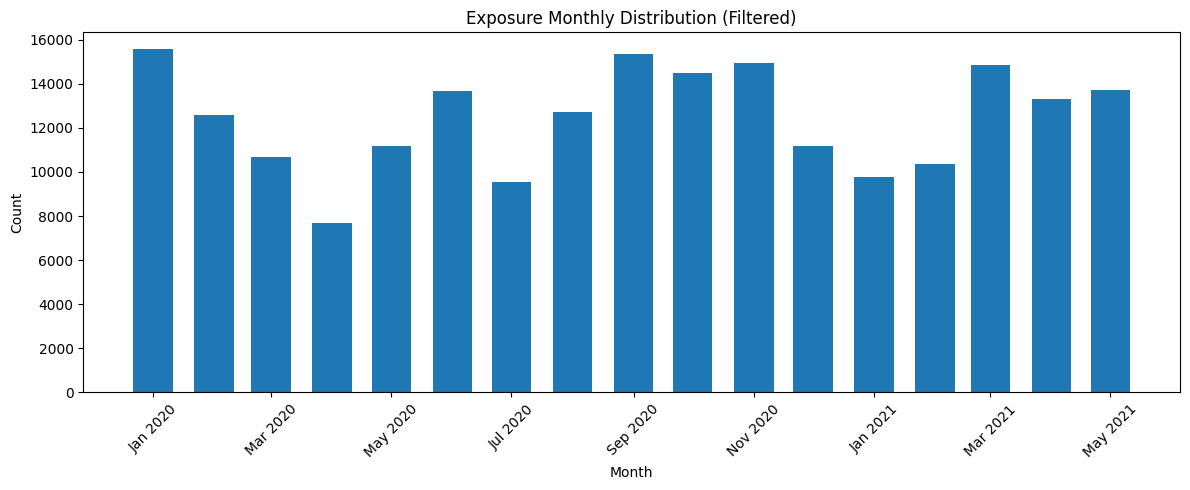

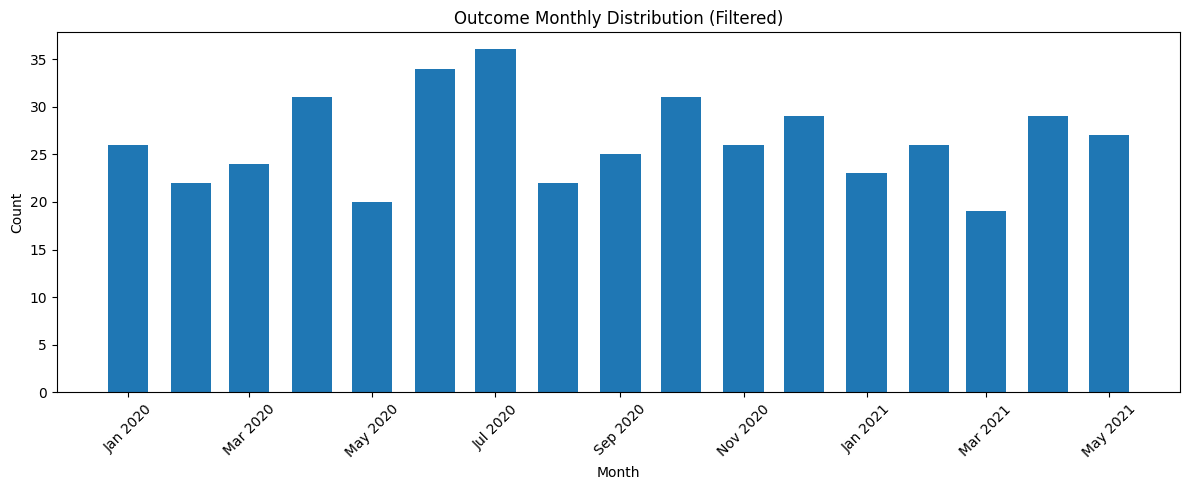

In [61]:
plot_monthly_distribution(
    exposure_filter,
    TIMESTAMP_COL,
    "Exposure Monthly Distribution (Filtered)"
)

plot_monthly_distribution(
    outcome_filter,
    TIMESTAMP_COL,
    "Outcome Monthly Distribution (Filtered)"
)

In [62]:
task_name = "ARF Prediction"

print(f"Task: {task_name}")         
print(f"   - Exposure data: {len(exposure_filter):,} records from {exposure_filter[PID_COL].nunique():,} unique patients")
print(f"   - Outcome data: {len(outcome_filter):,} records from {outcome_filter[PID_COL].nunique():,} unique patients")

Task: ARF Prediction
   - Exposure data: 211,570 records from 180,947 unique patients
   - Outcome data: 450 records from 435 unique patients


In [63]:
import os

# Local save directory
LOCAL_DIR = "./temp_data"
os.makedirs(LOCAL_DIR, exist_ok=True)

# Local file paths
EXPOSURE_LOCAL_PATH = os.path.join(LOCAL_DIR, "exposure_ARF_MDPS.csv")
OUTCOME_LOCAL_PATH = os.path.join(LOCAL_DIR, "outcome_ARF_MDPS.csv")

# Remote directory (ADLS)
REMOTE_DIR = "Zahra/032026/CoreBehrt_OOT/CreateOutcome_Finetune/ARF"

In [64]:
#  اینجا حتماً از filtered data استفاده کن
exposure_filter.to_csv(EXPOSURE_LOCAL_PATH, index=False)
outcome_filter.to_csv(OUTCOME_LOCAL_PATH, index=False)

print("Files saved locally:")
print(EXPOSURE_LOCAL_PATH)
print(OUTCOME_LOCAL_PATH)

Files saved locally:
./temp_data/exposure_ARF_MDPS.csv
./temp_data/outcome_ARF_MDPS.csv


In [65]:
from azureml.core import Workspace, Datastore
from azure.storage.filedatalake import DataLakeServiceClient
from azure.identity import DefaultAzureCredential
import os

# ---------- Azure Config ----------
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'
datastore_name = "researcher_data"

# ---------- Connect ----------
ws = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(ws, datastore_name)

account_name = datastore.account_name
filesystem_name = datastore.container_name

credential = DefaultAzureCredential()

# ---------- Upload Function ----------
def upload_to_adls2(local_file_path, remote_file_name, directory_path):
    
    # check file exists
    if not os.path.exists(local_file_path):
        raise FileNotFoundError(local_file_path)

    service_client = DataLakeServiceClient(
        account_url=f"https://{account_name}.dfs.core.windows.net",
        credential=credential
    )

    file_system_client = service_client.get_file_system_client(filesystem_name)

    # create directory if not exists
    directory_client = file_system_client.get_directory_client(directory_path)
    try:
        directory_client.create_directory()
    except:
        pass

    file_client = directory_client.get_file_client(remote_file_name)

    print(f"Uploading {remote_file_name} ...")

    with open(local_file_path, "rb") as f:
        file_client.upload_data(f, overwrite=True)

    print(f" Uploaded → {directory_path}/{remote_file_name}")


# ---------- Paths ----------
directory_path = "Zahra/032026/CoreBehrt_OOT/CreateOutcome_Finetune/ARF"

# ---------- Upload ----------
upload_to_adls2(
    "./temp_data/exposure_ARF_MDPS.csv",
    "exposure.csv",
    directory_path
)

upload_to_adls2(
    "./temp_data/outcome_ARF_MDPS.csv",
    "outcome.csv",
    directory_path
)

Uploading exposure.csv ...
 Uploaded → Zahra/032026/CoreBehrt_OOT/CreateOutcome_Finetune/ARF/exposure.csv
Uploading outcome.csv ...
 Uploaded → Zahra/032026/CoreBehrt_OOT/CreateOutcome_Finetune/ARF/outcome.csv


In [66]:
missing_pids = set(outcome_filter[PID_COL]) - set(exposure_filter[PID_COL])

print("Number of missing patients:", len(missing_pids))

Number of missing patients: 19


In [67]:
# Outcome (داخل بازه)
missing_outcome = outcome_filter[outcome_filter[PID_COL].isin(missing_pids)].copy()

# Exposure (بدون فیلتر زمانی!)
missing_exposure_all = exposure[exposure[PID_COL].isin(missing_pids)].copy()

In [68]:
missing_outcome[TIMESTAMP_COL] = pd.to_datetime(missing_outcome[TIMESTAMP_COL])
missing_exposure_all[TIMESTAMP_COL] = pd.to_datetime(missing_exposure_all[TIMESTAMP_COL])

missing_outcome = missing_outcome.sort_values([PID_COL, TIMESTAMP_COL])
missing_exposure_all = missing_exposure_all.sort_values([PID_COL, TIMESTAMP_COL])

In [69]:


summary = []

for pid in missing_pids:
    outcome_times = missing_outcome[missing_outcome[PID_COL] == pid][TIMESTAMP_COL]
    exposure_times = missing_exposure_all[missing_exposure_all[PID_COL] == pid][TIMESTAMP_COL]

    summary.append({
        "patient_id": pid,
        "outcome_min": outcome_times.min(),
        "outcome_max": outcome_times.max(),
        "n_outcome_records": len(outcome_times),
        "exposure_min": exposure_times.min() if len(exposure_times) > 0 else None,
        "exposure_max": exposure_times.max() if len(exposure_times) > 0 else None,
        "n_exposure_records": len(exposure_times)
    })

summary_df = pd.DataFrame(summary)

summary_df.head(10)

,patient_id,outcome_min,outcome_max,n_outcome_records,exposure_min,exposure_max,n_exposure_records
0,141576,2020-01-02,2020-01-02,1,2019-05-28,2019-12-03,2
1,1090696,2020-01-20,2020-01-20,1,2019-12-21,2019-12-21,1
2,1033738,2020-01-05,2020-01-05,1,2019-12-06,2019-12-06,1
3,188939,2020-01-12,2020-01-12,1,2019-10-11,2019-12-13,2
4,2146445,2020-01-25,2020-01-25,1,2019-12-26,2019-12-26,1
5,910352,2020-01-16,2020-01-16,1,2019-12-17,2019-12-17,1
6,1205011,2020-01-15,2020-01-15,1,2019-12-16,2021-07-23,2
7,615187,2020-01-08,2020-01-08,1,2019-12-09,2019-12-09,1
8,135957,2020-01-28,2020-01-28,1,2018-09-19,2019-12-29,2
9,808086,2020-01-07,2020-01-07,1,2018-05-16,2019-12-08,2


In [70]:
# چند نفر اصلاً exposure ندارن؟
no_exposure = summary_df[summary_df["n_exposure_records"] == 0]
print("Patients with NO exposure at all:", len(no_exposure))

# چند نفر exposure دارن ولی خارج از بازه؟
has_exposure = summary_df[summary_df["n_exposure_records"] > 0]

print("Patients with exposure but OUTSIDE time window:", len(has_exposure))

Patients with NO exposure at all: 0
Patients with exposure but OUTSIDE time window: 19


In [71]:
summary_df["time_diff_hours"] = (
    summary_df["outcome_min"] - summary_df["exposure_max"]
).dt.total_seconds() / 3600